# Problem D: Prediction of Traffic Flow based on Burgers’ Equation Model

Burgers' equation is a classical PDE model that captures the interplay between nonlinear convection and diffusion, making it well-suited for describing traffic flow dynamics. In this context, the convective term models the tendency for traffic to compress as vehicle density increases, while the diffusive term reflects the smoothing effect of individual driver reactions to surrounding traffic conditions.

The viscous Burgers' equation governing the evolution of vehicle velocity is:

$$
u_t + uu_x = \nu u_{xx}, \qquad x\in(-1,1),\ t\in(0,1] \tag{3}
$$

where:
- $u(x,t)$: vehicle velocity field (m/s),
- $\nu = 0.1/\pi$: kinematic viscosity coefficient (a higher value reflects more cautious, diffusive driver behavior),
- $x$: position along the road segment,
- $t$: time.

Homogeneous Dirichlet boundary conditions are imposed at both ends of the road:

$$
u(-1,\, t) = u(1,\, t) = 0, \qquad t \in (0, 1]
$$

Given an initial velocity profile $u(x, 0) = a(x)$, the full spatio-temporal velocity field $u(x,t)$ for $t > 0$ is uniquely determined by solving Eq. (3). In practice, however, running a high-fidelity finite difference solver for every new initial condition is computationally prohibitive. The goal of this task is therefore to learn a fast surrogate that approximates the solution operator $a(x) \mapsto u(x,t)$.

## Task: predicting the velocity filed $u(x,t)$ given the inital field $a(x)$ 

A dataset of initial conditions $a(x)$ sampled from a distribution $\mathcal{A}$ has been collected, along with the corresponding velocity fields $u(x,t)$ computed by a high-precision Finite Difference Method (FDM) solver. The dataset is **partially labeled**: only a small subset of initial conditions is paired with its FDM solution, while a much larger set of initial conditions has no corresponding solution available. This reflects a realistic scenario in which high-fidelity simulation data is scarce and expensive to obtain. The trained surrogate model should accurately predict $u(x,t)$ for any new initial condition $a(x)$ drawn from the same distribution $\mathcal{A}$, at negligible computational cost.

### Goals

- Select a suitable deep learning method for this task and justify your choice. 
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The error is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\displaystyle\sum_i\left|u^{(j)}_{\text{pred}}(x_i,t_i)-u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}{\displaystyle\sum_i\left|u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatio-temporal grid point.

- For the **first test instance**, use `matplotlib` to produce four separate figures:
  1. The initial condition $a(x) = u(x, 0)$
  2. The predicted velocity field $u_{\text{pred}}(x,t)$
  3. The ground truth velocity field $u_{\text{true}}(x,t)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

All data are provided in `ProblemD_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train_labeled` | (200, 256) | $N=200$ **labeled** initial fields, sampled at 256 spatial sensors |
| `u_train_labeled` | (200, 200, 256) | Corresponding FDM-computed velocity fields on a $200\times256$ spatio-temporal grid |
| `a_train_unlabeled` | (1800, 256) | $N=1800$ **unlabeled** initial fields (no paired solution available) |
| `a_test` | (200, 256) | Test initial conditions (**do not use for training**) |
| `u_test` | (200, 200, 256) | Ground truth velocity fields for test instances (**do not use for training**) |
| `x_mesh` | (256, 1) | Spatial coordinates of the 256 grid points |
| `t_mesh` | (200, 1) | Temporal coordinates of the 200 time steps |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['a_test', 'a_train_labeled', 'a_train_unlabeled', 't_mesh', 'u_test', 'u_train_labeled', 'x_mesh']>
t_mesh: torch.Size([200, 1]) x_mesh: torch.Size([256, 1])
a_train_labeled: torch.Size([200, 256]) u_train_labeled: torch.Size([200, 200, 256])
a_train_unlabeled: torch.Size([1800, 256])
a_test: torch.Size([200, 256]) u_test: torch.Size([200, 200, 256])


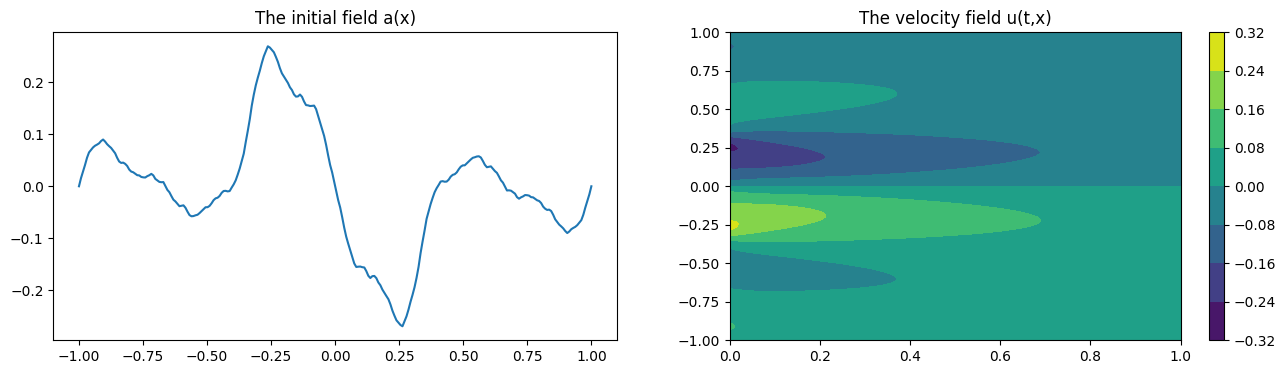

In [1]:
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
dtype = torch.float32
######################################
# Load training data
######################################
with h5py.File('Datasets\ProblemD_dataset.h5', 'r') as file:
    print(file.keys())
    t_mesh = torch.tensor(np.array(file['t_mesh']), dtype=dtype)
    x_mesh = torch.tensor(np.array(file['x_mesh']), dtype=dtype)
    a_test = torch.tensor(np.array(file['a_test']), dtype=dtype)
    u_test = torch.tensor(np.array(file['u_test']), dtype=dtype)
    a_train_labeled = torch.tensor(np.array(file['a_train_labeled']), dtype=dtype)
    u_train_labeled = torch.tensor(np.array(file['u_train_labeled']), dtype=dtype)
    a_train_unlabeled = torch.tensor(np.array(file['a_train_unlabeled']), dtype=dtype)
    #
    X, T = np.meshgrid(x_mesh, t_mesh)
#
print('t_mesh:', t_mesh.shape, 'x_mesh:', x_mesh.shape)
print('a_train_labeled:', a_train_labeled.shape, 'u_train_labeled:', u_train_labeled.shape)
print('a_train_unlabeled:', a_train_unlabeled.shape)
print('a_test:', a_test.shape, 'u_test:', u_test.shape)
#################################
inx = 0
fig, axes = plt.subplots(1,2, figsize=(16,4))
#
cntr = axes[0].plot(x_mesh, a_train_labeled[0])
axes[0].set_title('The initial field a(x)')
#
cntr = axes[1].contourf(T, X, u_train_labeled[inx])
axes[1].set_title('The velocity field u(t,x)')
plt.colorbar(cntr)
#
plt.show()

### Additional Imports and Device Setup

In [2]:
from torch.utils.data import Dataset, DataLoader

from tqdm import trange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataType = torch.float32

np.random.seed(1234)
torch.manual_seed(1234)

print(f"device: {device}")

device: cuda


### FNO input data preparation

In [3]:
# --- Convert numpy arrays to torch tensors ---
a_train_labeled_t = torch.tensor(a_train_labeled, dtype=dtype)
u_train_labeled_t = torch.tensor(u_train_labeled, dtype=dtype)

a_train_unlabeled_t = torch.tensor(a_train_unlabeled, dtype=dtype)

a_test_t = torch.tensor(a_test, dtype=dtype)
u_test_t = torch.tensor(u_test, dtype=dtype)

x_mesh_t = torch.tensor(x_mesh, dtype=dtype)
t_mesh_t = torch.tensor(t_mesh, dtype=dtype)

# Add one channel dimension to u
u_train_labeled_t = u_train_labeled_t.unsqueeze(-1)
u_test_t = u_test_t.unsqueeze(-1)

# Repeat initial condition a(x) along the time direction
a_train_labeled_t = a_train_labeled_t.unsqueeze(1).repeat(1, u_train_labeled_t.shape[1], 1).unsqueeze(-1)
a_train_unlabeled_t = a_train_unlabeled_t.unsqueeze(1).repeat(1, u_train_labeled_t.shape[1], 1).unsqueeze(-1)
a_test_t = a_test_t.unsqueeze(1).repeat(1, u_test_t.shape[1], 1).unsqueeze(-1)

# Convert coordinate vectors to full space-time grids
x_vec = x_mesh_t.squeeze()   # [256]
t_vec = t_mesh_t.squeeze()   # [200]

x_mesh_t = x_vec.unsqueeze(0).repeat(u_train_labeled_t.shape[1], 1)  # [200, 256]
t_mesh_t = t_vec.unsqueeze(1).repeat(1, u_train_labeled_t.shape[2])  # [200, 256]

x_mesh_t = x_mesh_t.unsqueeze(-1)
t_mesh_t = t_mesh_t.unsqueeze(-1)

# Repeat coordinate grids for all samples
x_train_labeled = x_mesh_t.unsqueeze(0).repeat(a_train_labeled_t.shape[0], 1, 1, 1)
t_train_labeled = t_mesh_t.unsqueeze(0).repeat(a_train_labeled_t.shape[0], 1, 1, 1)

x_train_unlabeled = x_mesh_t.unsqueeze(0).repeat(a_train_unlabeled_t.shape[0], 1, 1, 1)
t_train_unlabeled = t_mesh_t.unsqueeze(0).repeat(a_train_unlabeled_t.shape[0], 1, 1, 1)

x_test = x_mesh_t.unsqueeze(0).repeat(a_test_t.shape[0], 1, 1, 1)
t_test = t_mesh_t.unsqueeze(0).repeat(a_test_t.shape[0], 1, 1, 1)

# Concatenate initial condition and coordinates as FNO input
# Input channels: [a, x, t]
axt_train_labeled = torch.cat([a_train_labeled_t, x_train_labeled, t_train_labeled], dim=-1)
axt_train_unlabeled = torch.cat([a_train_unlabeled_t, x_train_unlabeled, t_train_unlabeled], dim=-1)
axt_test = torch.cat([a_test_t, x_test, t_test], dim=-1)

# --- prints ---
print("axt_train_labeled shape:", axt_train_labeled.shape)
print("u_train_labeled shape:", u_train_labeled_t.shape)

print("axt_train_unlabeled shape:", axt_train_unlabeled.shape)

print("axt_test shape:", axt_test.shape)
print("u_test shape:", u_test_t.shape)

C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_7720\4291432591.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a_train_labeled_t = torch.tensor(a_train_labeled, dtype=dtype)
C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_7720\4291432591.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_train_labeled_t = torch.tensor(u_train_labeled, dtype=dtype)
C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_7720\4291432591.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a_train_unlabeled_t = torch.tensor(a_

axt_train_labeled shape: torch.Size([200, 200, 256, 3])
u_train_labeled shape: torch.Size([200, 200, 256, 1])
axt_train_unlabeled shape: torch.Size([1800, 200, 256, 3])
axt_test shape: torch.Size([200, 200, 256, 3])
u_test shape: torch.Size([200, 200, 256, 1])


### The FNO architecture

In [4]:
# Spectral Convolution layer - 2d

class SpectralConv2d(torch.nn.Module):
    
    def __init__(self, in_size, out_size, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        Inputs:
            in_size: number of input channels
            out_size: number of output channels
            modes1: number of Fourier modes kept in x-direction
            modes2: number of Fourier modes kept in y-direction
        """

        self.in_size = in_size
        self.out_size = out_size
        self.modes1 = modes1
        self.modes2 = modes2

        # Scaling factor
        self.scale = 1 / (in_size * out_size)

        # Learnable complex weights
        self.weights1 = torch.nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = torch.nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        """
        Complex multiplication
        """
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        """
        Forward pass of the spectral convolution.
        """

        batchsize = x.shape[0]

        # Compute Fourier coefficients (transformation to fourier space)
        x_ft = torch.fft.rfft2(x)

        # Allocate output tensor in Fourier space
        out_ft = torch.zeros(batchsize, self.out_size, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)

        # Multiply selected low-frequency Fourier modes
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        # Transform back to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x

In [5]:
# Fourier Neural Operator (FNO) - 2d

class FNO2d(torch.nn.Module):
    
    def __init__(self, modes1, modes2, width, in_size=3, out_size=1):
        super(FNO2d, self).__init__()

        """
        Inputs:
            modes1: number of Fourier modes kept in x-direction
            modes2: number of Fourier modes kept in y-direction
            width: number of hidden channels
            in_size: number of input channels for Problem C: [a, X, Y] -> 3
            out_size: number of output channels for Problem C: [u] -> 1
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width

        # Lift input channels to hidden channels
        self.fc_in = torch.nn.Linear(in_size, width)

        # Fourier convolution layers
        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)

        # Pointwise 1x1 convolution layers
        self.w0 = torch.nn.Conv2d(width, width, 1)
        self.w1 = torch.nn.Conv2d(width, width, 1)
        self.w2 = torch.nn.Conv2d(width, width, 1)
        self.w3 = torch.nn.Conv2d(width, width, 1)

        # Project hidden channels back to output field
        self.fc_out0 = torch.nn.Linear(width, 128)
        self.fc_out1 = torch.nn.Linear(128, out_size)

        self.activation = torch.nn.GELU()

    def forward(self, x):
        """
        Forward pass.
        """

        # Lift input from in_size channels to width channels
        x = self.fc_in(x)

        # Change shape from [batch, nt, nx, width]
        # to [batch, width, nt, nx] for convolution layers
        x = x.permute(0, 3, 1, 2)

        # Fourier layer 1
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = self.activation(x1 + x2)

        # Fourier layer 2
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = self.activation(x1 + x2)

        # Fourier layer 3
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = self.activation(x1 + x2)

        # Fourier layer 4
        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = self.activation(x1 + x2)

        # Change shape back from [batch, width, nt, nx]
        # to [batch, nt, nx, width]
        x = x.permute(0, 2, 3, 1)

        # Project hidden channels to output u
        x = self.activation(self.fc_out0(x))
        x = self.fc_out1(x)

        return x

### Loss Function

In [6]:
# Normalizer

class UnitGaussianNormalizer():
    
    def __init__(self, ax, eps=1e-8):
        super(UnitGaussianNormalizer, self).__init__()
        
        """
        Unit Gaussian normalizer.

        For ax = [a, x, t], only the first channel a is normalized.
        For u = [u], the only channel u is normalized.
        """

        # Compute mean and standard deviation over the sample dimension
        self.mean = torch.mean(ax[..., 0:1], dim=0)
        self.std = torch.std(ax[..., 0:1], dim=0)
        self.eps = eps
    
    def encode(self, ax):
        """
        Normalize the first channel.
        For ax = [a, x, t], this normalizes a and keeps x,t unchanged.
        """

        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)

        ax = torch.cat([(ax_list[0] - self.mean) / (self.std + self.eps), ax_list[1]], dim=-1)

        return ax
    
    def decode(self, ax):
        """
        Undo the normalization of the first channel.
        """

        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)

        ax = torch.cat([ax_list[0] * (self.std + self.eps) + self.mean, ax_list[1]], dim=-1)

        return ax


# Create normalizers using training data only
normalizer_axt = UnitGaussianNormalizer(axt_train_labeled.to(device))
normalizer_u = UnitGaussianNormalizer(u_train_labeled_t.to(device))

In [7]:
# Hard constraint / mollifier

class mollifier(object):

    def __init__(self):
        super(mollifier, self).__init__()

    def __call__(self, u_raw, axt):
        """
        Apply hard initial and boundary constraints.
        """

        # Extract channels
        a = axt[..., 0:1]   # initial condition a(x)
        x = axt[..., 1:2]   # spatial coordinate x
        t = axt[..., 2:3]   # time coordinate t

        # Hard-constrained output:
        # u(x,t) = a(x) + t(1 - x^2)N(a,x,t)
        u = a + t * (1.0 - x**2) * u_raw

        return u


# Loss function and Relative error (L2)

class LossFNO():
    
    def __init__(self, model_u, normalizer_axt, normalizer_u):
        self.model_u = model_u
        self.normalizer_axt = normalizer_axt
        self.normalizer_u = normalizer_u
        self.getLoss = torch.nn.MSELoss()   # Mean Squared Error loss function
        self.mollifier = mollifier()

    # --- supervised data loss term ---
    def loss_data(self, axt, u):

        # Move batch to device
        axt = axt.to(device)
        u = u.to(device)

        # Normalize input
        axt_norm = self.normalizer_axt.encode(axt)

        # Predict normalized velocity field
        u_raw_norm = self.model_u(axt_norm)

        # Decode prediction back to physical scale
        u_raw = self.normalizer_u.decode(u_raw_norm)

        # Apply hard initial and boundary constraints
        u_pred = self.mollifier(u_raw, axt)

        # Mean Squared Error
        loss = self.getLoss(u_pred, u)

        return loss

    # --- physics-informed loss terms ---
    # PDE loss
    def loss_pde(self, axt):

        # Move batch to device
        axt = axt.to(device)

        # Normalize input
        axt_norm = self.normalizer_axt.encode(axt)

        # Predict normalized velocity field
        u_raw_norm = self.model_u(axt_norm)

        # Decode prediction back to physical scale
        u_raw = self.normalizer_u.decode(u_raw_norm)

        # Apply hard initial and boundary constraints
        u_pred = self.mollifier(u_raw, axt)

        # Remove channel dimension
        # Shape: [batch, Nt, Nx, 1] -> [batch, Nt, Nx]
        u = u_pred[..., 0]

        # Extract x and t from input channels
        # axt channels: [a, x, t]
        x = axt[..., 1]
        t = axt[..., 2]

        # Grid spacing
        dx = x[0, 0, 1] - x[0, 0, 0]
        dt = t[0, 1, 0] - t[0, 0, 0]

        # Central finite differences on interior points
        u_t = (u[:, 2:, 1:-1] - u[:, :-2, 1:-1]) / (2.0 * dt)
        u_x = (u[:, 1:-1, 2:] - u[:, 1:-1, :-2]) / (2.0 * dx)
        u_xx = (u[:, 1:-1, 2:] - 2.0 * u[:, 1:-1, 1:-1] + u[:, 1:-1, :-2]) / (dx ** 2)

        # Interior value of u
        u_mid = u[:, 1:-1, 1:-1]

        # residual: R = u_t + u u_x - nu u_xx [LHS - RHS]
        nu = 0.1 / np.pi    # given
        residual = u_t + u_mid * u_x - nu * u_xx

        # Mean Squared Error
        loss = self.getLoss(residual, torch.zeros_like(residual))

        return loss
    
    # Total loss
    def loss_total(self, axt_unlabeled, axt_labeled=None, u_labeled=None,
                   w_data=1.0, w_pde=1.0):

        # PDE loss on unlabelled data
        loss_pde = self.loss_pde(axt_unlabeled)

        # Total physics-informed loss
        loss = w_pde * loss_pde

        # Optional supervised data loss on labelled data
        if axt_labeled is not None and u_labeled is not None:
            loss_data = self.loss_data(axt_labeled, u_labeled)
            loss = loss + w_data * loss_data
        else:
            loss_data = torch.tensor(0.0, dtype=loss.dtype, device=loss.device)

        return loss, loss_data, loss_pde

    # --- L2 error ---
    def relative_l2_error(self, axt, u):

        with torch.no_grad():
            axt = axt.to(device)
            u = u.to(device)

            # Normalize input
            axt_norm = self.normalizer_axt.encode(axt)

            # Predict normalized output
            u_raw_norm = self.model_u(axt_norm)

            # Decode prediction back to physical scale
            u_raw = self.normalizer_u.decode(u_raw_norm)

            # Apply hard initial and boundary constraints
            u_pred = self.mollifier(u_raw, axt)

            # Relative L2 error per sample
            error = torch.norm(u_pred.reshape(u_pred.shape[0], -1) - u.reshape(u.shape[0], -1),  p=2, dim=1) / torch.norm(u.reshape(u.shape[0], -1), p=2, dim=1)

            # Mean relative L2 error over all samples
            error = torch.mean(error)

        return error.item()

### Training

In [8]:
# Create Data Loaders for Batch Training

class MyDataset_Labelled(Dataset):

    def __init__(self, axt: torch.tensor, u: torch.tensor):
        self.axt = axt
        self.u = u
    
    def __getitem__(self, index):
        return self.axt[index], self.u[index]

    def __len__(self):
        return self.axt.shape[0]


class MyDataset_Unlabelled(Dataset):

    def __init__(self, axt: torch.tensor):
        self.axt = axt
    
    def __getitem__(self, index):
        return self.axt[index]

    def __len__(self):
        return self.axt.shape[0]
    
batch_size_labeled = 10
batch_size_unlabeled = 10

train_labeled_loader = DataLoader(MyDataset_Labelled(axt_train_labeled, u_train_labeled_t), batch_size=batch_size_labeled, shuffle=True)
train_unlabeled_loader = DataLoader(MyDataset_Unlabelled(axt_train_unlabeled), batch_size=batch_size_unlabeled, shuffle=True)

In [9]:
# Training setup

# FNO hyperparameters
modes1 = 20
modes2 = 32
width = 32

# Training hyperparameters
epochs = 100
learning_rate = 1e-3

w_data = 1.0    # data loss weight
w_pde = 0.5     # pde loss weight

model_u = FNO2d(modes1=modes1, modes2=modes2, width=width, in_size=3, out_size=1).to(device)

optimizer = torch.optim.Adam(model_u.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

lossClass = LossFNO(model_u=model_u, normalizer_axt=normalizer_axt, normalizer_u=normalizer_u)

# Store training history
loss_train_history = []
l2_test_history = []

print(model_u)

FNO2d(
  (fc_in): Linear(in_features=3, out_features=32, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (conv3): SpectralConv2d()
  (w0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (w1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (w3): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (fc_out0): Linear(in_features=32, out_features=128, bias=True)
  (fc_out1): Linear(in_features=128, out_features=1, bias=True)
  (activation): GELU(approximate='none')
)


In [10]:
# Training Process

loss_train_history = []
l2_test_history = []

loss_data_history = []
loss_pde_history = []

for epoch in trange(epochs):

    model_u.train()
    epoch_loss = 0.0
    epoch_data_loss = 0.0
    epoch_pde_loss = 0.0

    unlabelled_iter = iter(train_unlabeled_loader)  # iterator for unlabelled

    # ---- Training over mini-batches ----
    for axt_labeled_batch, u_labeled_batch in train_labeled_loader:

        # Get one unlabelled batch
        axt_unlabeled_batch = next(unlabelled_iter)

        # Total PINO loss
        loss_train, loss_data, loss_pde = lossClass.loss_total(axt_unlabeled=axt_unlabeled_batch, axt_labeled=axt_labeled_batch, u_labeled=u_labeled_batch, w_data=w_data, w_pde=w_pde)

        # Backpropagation
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        epoch_loss += loss_train.item()
        epoch_data_loss += loss_data.item()
        epoch_pde_loss += loss_pde.item()

    scheduler.step()

    # Average losses over labelled batches
    epoch_loss /= len(train_labeled_loader)
    epoch_data_loss /= len(train_labeled_loader)
    epoch_pde_loss /= len(train_labeled_loader)

    loss_train_history.append(epoch_loss)
    loss_data_history.append(epoch_data_loss)
    loss_pde_history.append(epoch_pde_loss)

    # Evaluate on test set
    error_test = lossClass.relative_l2_error(axt_test, u_test_t)
    l2_test_history.append(error_test)

    if (epoch + 1) % max(1, epochs // 4) == 0:
        print(
            f"Epoch {epoch+1:4d} | "
            f"Loss: {epoch_loss:.4e} | "
            f"Data: {epoch_data_loss:.4e} | "
            f"PDE: {epoch_pde_loss:.4e} | "
            f"Test L2 rel. error: {error_test:.4e}"
        )

 25%|██▌       | 25/100 [56:05<3:07:51, 150.29s/it]

Epoch   25 | Loss: 5.0371e-02 | Data: 7.1704e-04 | PDE: 9.9308e-02 | Test L2 rel. error: 2.3992e-01


 50%|█████     | 50/100 [2:00:01<2:11:25, 157.71s/it]

Epoch   50 | Loss: 2.7130e-02 | Data: 5.0083e-04 | PDE: 5.3258e-02 | Test L2 rel. error: 1.8945e-01


 75%|███████▌  | 75/100 [3:03:24<1:06:39, 159.99s/it]

Epoch   75 | Loss: 3.4340e-02 | Data: 4.9532e-04 | PDE: 6.7690e-02 | Test L2 rel. error: 1.8139e-01


100%|██████████| 100/100 [4:05:00<00:00, 147.01s/it] 

Epoch  100 | Loss: 2.5717e-02 | Data: 4.5649e-04 | PDE: 5.0522e-02 | Test L2 rel. error: 1.8232e-01


### Visualization

In [11]:
# -----------------------------
# Prediction with trained model
# -----------------------------

sample_index = 0    # sample to visualize

model_u.eval()

with torch.no_grad():
    
    # Take one test sample
    axt_sample = axt_test[sample_index:sample_index+1].to(device)
    u_true_sample = u_test_t[sample_index:sample_index+1].to(device)

    # Normalize input
    axt_sample_norm = normalizer_axt.encode(axt_sample)

    # Predict normalized output
    u_raw_norm = model_u(axt_sample_norm)

    # Decode prediction back to physical scale
    u_raw = normalizer_u.decode(u_raw_norm)

    # Apply hard initial and boundary constraints
    u_pred_sample = lossClass.mollifier(u_raw, axt_sample)

# Convert to numpy for plotting
a_plot = axt_test[sample_index, 0, :, 0].detach().cpu().numpy()
u_true_plot = u_true_sample[0, :, :, 0].detach().cpu().numpy()
u_pred_plot = u_pred_sample[0, :, :, 0].detach().cpu().numpy()
abs_error_plot = np.abs(u_pred_plot - u_true_plot)

# Coordinate vectors
x_plot = x_mesh_t[0, :, 0].detach().cpu().numpy()
t_plot = t_mesh_t[:, 0, 0].detach().cpu().numpy()

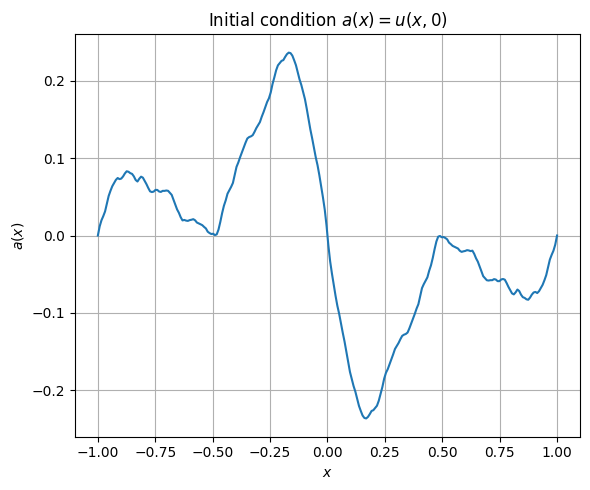

In [12]:
# -----------------------------
# Plot initial condition a(x)
# -----------------------------

plt.figure(figsize=(6, 5))
plt.plot(x_plot, a_plot)
plt.title(r"Initial condition $a(x)=u(x,0)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$a(x)$")
plt.grid(True)
plt.tight_layout()
plt.show()

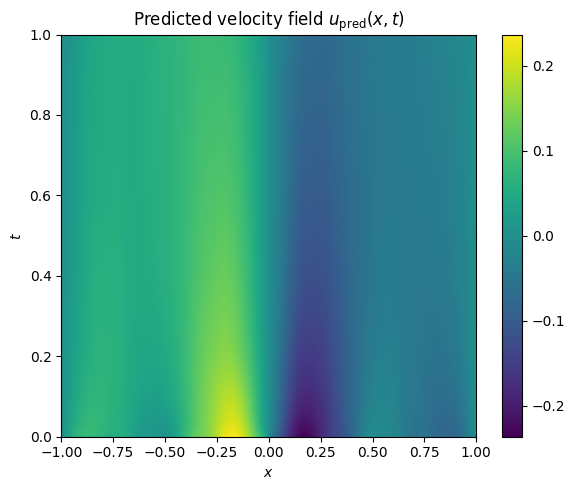

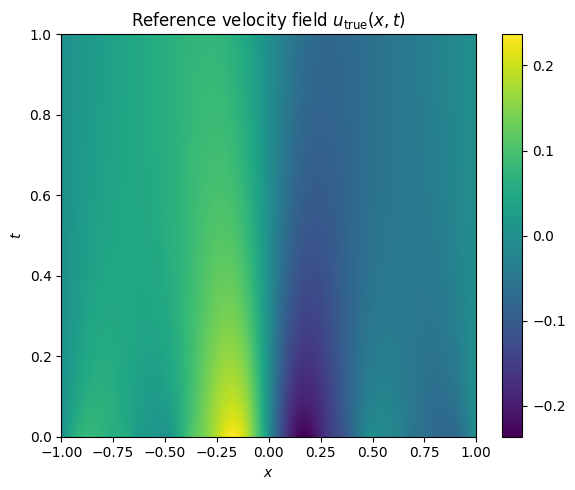

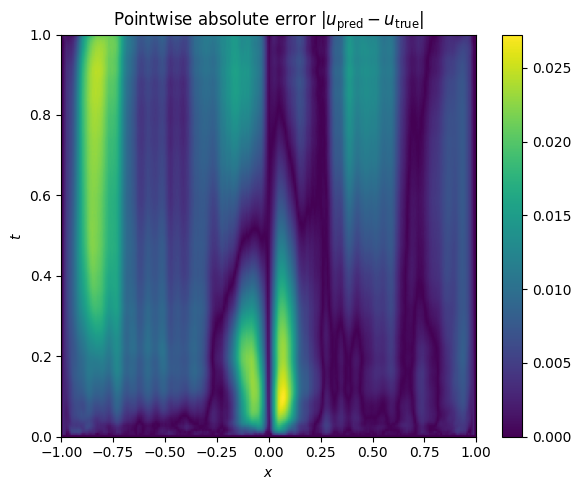

In [13]:
# -----------------------------
# Plot predicted velocity field u_pred(x,t)
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(u_pred_plot,origin="lower",extent=[x_plot.min(), x_plot.max(), t_plot.min(), t_plot.max()],aspect="auto")
plt.colorbar()
plt.title(r"Predicted velocity field $u_{\mathrm{pred}}(x,t)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$t$")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot reference velocity field u_true(x,t)
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(u_true_plot,origin="lower",extent=[x_plot.min(), x_plot.max(), t_plot.min(), t_plot.max()],aspect="auto")
plt.colorbar()
plt.title(r"Reference velocity field $u_{\mathrm{true}}(x,t)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$t$")
plt.tight_layout()
plt.show()

# -----------------------------
# Pointwise absolute error for u
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(abs_error_plot,origin="lower",extent=[x_plot.min(), x_plot.max(), t_plot.min(), t_plot.max()],aspect="auto")
plt.colorbar()
plt.title(r"Pointwise absolute error $|u_{\mathrm{pred}}-u_{\mathrm{true}}|$")
plt.xlabel(r"$x$")
plt.ylabel(r"$t$")
plt.tight_layout()
plt.show()

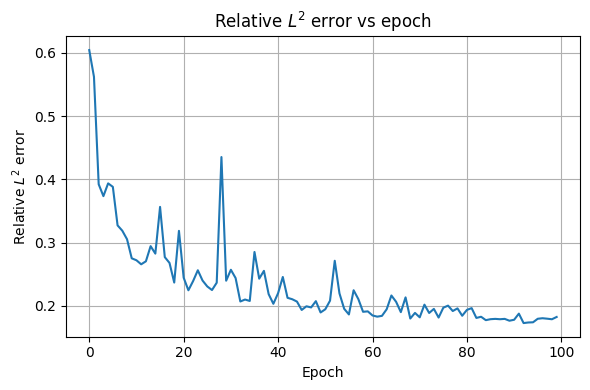

In [14]:
# -----------------------------
# Error vs. epoch
# -----------------------------

plt.figure(figsize=(6, 4))
plt.plot(l2_test_history)
plt.xlabel("Epoch")
plt.ylabel(r"Relative $L^2$ error")
plt.title(r"Relative $L^2$ error vs epoch")
plt.grid(True)
plt.tight_layout()
plt.show()